# 최대전력수요 예측 Baseline code
LSTM-encoder decoder 형식을 이용하여 다음 데이터를 예측한다.

## 1. 필요 패키지 호출

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
from baseline_LSTM import Seq2SeqLSTM

## 2. 데이터 호출 및 데이터 분리

데이터는 15분 단위의 전력량, 공장인원, 가동 여부, 휴일 여부, 시간, 요일, 하루 전 전력량, 일주일 전 전력량, 1시간 전 가동 여부로 구성된다.

In [6]:
csv_path = os.path.join('dataset', 'data_final.csv')

dataset = pd.read_csv(
    csv_path,
    index_col='Date',
    parse_dates=['Date']
)

dataset.head()

,전력량,공장 인원,is_operated,Vacation,time_sin,time_cos,day_0,day_1,day_2,day_3,day_4,day_5,day_6,전력량_1일전,전력량_1주일전,is_operated_1시간전,is_operated_1일전
Date,,,,,,,,,,,,,,,,,
2021-01-08 00:15:00,64.0,0.0,0.0,0.0,0.065403,0.997859,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,62.0,1.0,0.0
2021-01-08 00:30:00,63.0,0.0,0.0,0.0,0.130526,0.991445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0,1.0,0.0
2021-01-08 00:45:00,63.0,0.0,0.0,0.0,0.195090,0.980785,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0,1.0,0.0
2021-01-08 01:00:00,62.0,0.0,0.0,0.0,0.258819,0.965926,0.0,0.0,0.0,0.0,1.0,0.0,0.0,25.0,61.0,1.0,0.0
2021-01-08 01:15:00,87.0,0.0,0.0,0.0,0.321439,0.946930,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.0,96.0,0.0,1.0


학습 데이터, 검증 데이터, 테스트 데이터의 비율을 6:2:2로 설정한다.

In [7]:
idx = dataset.index

split1 = idx[int(len(idx) * 0.6)].ceil('D')
split2 = idx[int(len(idx) * 0.8)].ceil('D')

print(f'검증 셋 기준 날짜 : {split1}')
print(f'테스트 셋 기준 날짜 : {split2}')

검증 셋 기준 날짜 : 2021-06-08 00:00:00
테스트 셋 기준 날짜 : 2021-07-28 00:00:00


MinMaxScaler를 이용하여 전력량과 공장인원에 대한 정규화를 실시한다.

### MinMaxScaler

`MinMaxScaler`는 각 피처의 값을 일정한 범위로 선형 변환하는 전처리 방법이다. 여기서는 기본 설정인 0과 1 사이로 변환한다.

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

- `power_scaler`는 전력량과 전력량의 과거 시점 피처에 사용한다.
- `people_scaler`는 공장인원 피처에 사용한다.
- 두 스케일러 모두 검증·테스트 데이터의 정보가 학습에 섞이지 않도록 학습 데이터(`train_mask`)에만 `fit`한다.
- 모델의 예측값을 원래 전력량 단위로 해석할 때는 `power_scaler.inverse_transform()`을 사용한다.

이처럼 피처별로 스케일러를 분리하면 전력량과 공장인원의 값 범위가 서로 달라도 안정적으로 학습할 수 있다.

In [8]:
power_scaler = MinMaxScaler()
people_scaler = MinMaxScaler()

train_mask = idx < split1

power_scaler.fit(dataset.loc[train_mask, ['전력량']])
people_scaler.fit(dataset.loc[train_mask, ['공장 인원']])

dataset_scaled = dataset.copy()

dataset_scaled[['전력량']] = power_scaler.transform(
    dataset[['전력량']]
)
dataset_scaled[['전력량_1일전']] = power_scaler.transform(
    dataset[['전력량_1일전']].rename(columns={'전력량_1일전': '전력량'})
)
dataset_scaled[['전력량_1주일전']] = power_scaler.transform(
    dataset[['전력량_1주일전']].rename(columns={'전력량_1주일전': '전력량'})
)

dataset_scaled[['공장 인원']] = people_scaler.transform(
    dataset[['공장 인원']]
)

### LSTM 입력 시퀀스 구성

15분 단위 데이터에서는 하루가 96개 시점(24시간 × 4개 구간)으로 구성된다. 따라서 LSTM에 입력하기 위해 데이터를 하루 단위인 96개씩 묶는다.

`make_sequences` 함수는 각 예측 시점마다 다음과 같이 데이터를 구성한다.

- `X`: 현재 시점 이전의 과거 96개 시점. LSTM encoder가 과거의 전력량과 관련 피처를 학습하는 입력이다.
- `C`: 현재 시점부터 앞으로 96개 시점에 대해 이미 알고 있는 미래 정보(`FUTURE_COLS`). 이 `future` 데이터는 LSTM decoder에 넣어 예측 대상 구간의 조건으로 사용한다.
- `y`: `X` 다음에 이어지는 미래 96개 시점의 실제 전력량. 모델이 예측해야 하는 정답이다.

즉, 하나의 학습 샘플은 **과거 하루(96개) → 미래 하루(96개) 예측** 형태로 만들어진다. 반복문은 시작 위치를 한 시점씩 이동하며 이러한 입력과 정답 쌍을 생성하므로, 반환되는 배열의 형태는 각각 `(샘플 수, 96, 특성 수)`, `(샘플 수, 96, 미래 특성 수)`, `(샘플 수, 96)`이 된다.

In [9]:
# LSTM decoder에 넣을 데이터 분리 : 미래에 알 수 있는 피쳐만 추출
FUTURE_COLS = ['Vacation', 'time_sin', 'time_cos', 
                'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6',
                '전력량_1일전', '전력량_1주일전',]
 
def make_sequences(data, future_cols=FUTURE_COLS, window_size=96, horizon=96):
    past = data.values                       
    future = data[future_cols].values        
    target = data['전력량'].values
 
    X, C, y = [], [], []
    for i in range(window_size, len(data) - horizon + 1):
        X.append(past[i - window_size: i])        
        C.append(future[i: i + horizon])         
        y.append(target[i: i + horizon])        
 
    return (
        np.array(X, dtype=np.float32),
        np.array(C, dtype=np.float32),
        np.array(y, dtype=np.float32),
    )

앞서 만든 함수를 적용한 뒤, 학습, 검증, 데이터 셋으로 분리한다.

In [10]:
window_size = 96
horizon_size = 96

X, C, y = make_sequences(dataset_scaled, FUTURE_COLS, window_size, horizon_size)

t_start = dataset_scaled.index[window_size : len(dataset_scaled) - horizon_size + 1]  
t_end   = dataset_scaled.index[window_size + horizon_size - 1 :]   

In [11]:
train_split = t_end < split1
valid_split = (t_start >= split1) & (t_end < split2)
test_split  = t_start >= split2

X_train, C_train, y_train = X[train_split], C[train_split], y[train_split]
X_valid, C_valid, y_valid = X[valid_split], C[valid_split], y[valid_split]
X_test, C_test, y_test  = X[test_split], C[test_split], y[test_split]

print(f'훈련 셋 X : {X_train.shape}, y : {y_train.shape}')
print(f'검증 셋 X : {X_valid.shape}, y : {y_valid.shape}')
print(f'테스트 셋 X : {X_test.shape}, y : {y_test.shape}')

훈련 셋 X : (14304, 96, 17), y : (14304, 96)
검증 셋 X : (4705, 96, 17), y : (4705, 96)
테스트 셋 X : (4610, 96, 17), y : (4610, 96)


이후 pytorch에서  사용하기 위해 tensor형태로 전환한다.

In [12]:
X_train = torch.tensor(X_train, dtype=torch.float32)
C_train = torch.tensor(C_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_valid = torch.tensor(X_valid, dtype=torch.float32)
C_valid = torch.tensor(C_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
C_test = torch.tensor(C_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### DataLoader

`DataLoader`는 데이터를 64개 샘플씩 묶어 모델에 전달한다. 학습 데이터는 매 epoch마다 순서를 섞고(`shuffle=True`), 검증·테스트 데이터는 평가 결과의 일관성을 위해 순서를 유지한다(`shuffle=False`).

In [13]:
train_dataset = TensorDataset(X_train, C_train, y_train)
valid_dataset = TensorDataset(X_valid, C_valid, y_valid)
test_dataset  = TensorDataset(X_test,  C_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## 3. 모델 호출 및 예측

`baseline_LSTM.py`에서 정의한 `Seq2SeqLSTM` 모델을 불러와 사용한다. 모델은 encoder가 과거 입력 `X`를 처리하고, decoder가 미래에 알고 있는 정보 `future(C)`를 사용해 다음 96개 시점의 전력량을 예측하는 구조이다.

- `input_size=X_train.size(2)`: encoder에 입력되는 과거 데이터의 특성 개수
- `future_size=C_train.size(2)`: decoder에 입력되는 미래 정보의 특성 개수
- `hidden_size=128`: LSTM이 시계열 정보를 표현하는 은닉 상태의 크기
- `num_layers=2`: encoder와 decoder에 쌓는 LSTM 층의 수
- `dropout=0.2`: 과적합을 줄이기 위해 일부 연결을 무작위로 제외하는 비율

마지막의 `.to(device)`는 CUDA GPU를 사용할 수 있으면 GPU에, 그렇지 않으면 CPU에 모델을 배치한다.

In [24]:
# Cuda 환경에서 실행이 가능하다면 Cuda 환경을 사용한다. 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 가능한 기기 : {device}')

model = Seq2SeqLSTM(
    input_size=X_train.size(2),
    future_size=C_train.size(2),
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
).to(device)

사용 가능한 기기 : cpu


### 모델 실행을 위한 기본 세팅

- `criterion = nn.L1Loss()`: 예측값과 실제값의 절대 오차 평균(MAE)을 손실 함수로 사용한다.
- `optimizer = optim.AdamW(...)`: 모델의 가중치를 업데이트하는 AdamW optimizer를 사용한다. `lr=2e-4`는 초기 학습률이고, `weight_decay=1e-5`는 과적합을 줄이기 위한 가중치 감쇠 값이다.
- `ReduceLROnPlateau`: 검증 손실(`valid_loss`)이 `patience=10` epoch 동안 좋아지지 않으면 학습률을 `factor=0.5`배로 줄인다. `mode='min'`은 손실이 낮아지는 것을 개선으로 판단한다.
- `num_epoch = 150`: 학습 데이터를 최대 150번 반복해 학습한다. 실제 학습은 이후 셀의 조기 종료 조건에 따라 더 일찍 끝날 수 있다.

In [25]:
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      
    factor=0.5,    
    patience=10     
)
num_epoch = 150

### 실제 모델 실행
모델은 학습 셋을 이용한 학습과, 검증 셋을 이용한 오차 검증으로 이루어진다.

검증 셋에 대한 점수가 20번 연속으로 작아지지 않는다면 조기 종료 시킨다. 

In [26]:
train_loss_graph = []
valid_loss_graph = []

# early stopping을 위한 세팅
patience = 20
best_valid_loss = float('inf')
patience_count = 0

for epoch in range(num_epoch):
    train_loss = 0.0
    valid_loss = 0.0

    # 모델 학습
    model.train()

    for x, c, y in train_loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        pred = model(x, c)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # 모델 평가
    model.eval()

    with torch.no_grad():
        for x, c, y in valid_loader:
            x, c, y = x.to(device), c.to(device), y.to(device)
            pred = model(x, c)
            loss = criterion(pred, y)
            valid_loss += loss.item()

    train_loss /= len(train_loader)
    valid_loss /= len(valid_loader)

    scheduler.step(valid_loss)
    
    train_loss_graph.append(train_loss)
    valid_loss_graph.append(valid_loss)

    # early-stopping 
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_count = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        patience_count += 1

    if epoch % 10 == 0:
        print(
            f'[epoch: {epoch}] '
            f'train loss: {train_loss:.4f}, '
            f'valid loss: {valid_loss:.4f}'
        )

    if patience_count >= patience:
        print(f'Early stopping at epoch {epoch}\n train loss: {train_loss:.4f}, '
              f'valid loss: {valid_loss:.4f}')
        break

[epoch: 0] train loss: 0.1902, valid loss: 0.0762
[epoch: 10] train loss: 0.0667, valid loss: 0.0461
[epoch: 20] train loss: 0.0582, valid loss: 0.0493
Early stopping at epoch 26
 train loss: 0.0572, valid loss: 0.0512


학습 과정에서 훈련 셋과 검증 셋의 오차가 전반적으로 감소하는 경향을 보인다.
다만 마지막 구간에서 검증 셋의 오차가 다시 증가하는 현상이 나타난다.
이는 모델이 학습 데이터에 과도하게 적합되었거나 학습이 불안정해졌을 가능성을 보여준다.
따라서 검증 손실이 가장 낮았던 시점의 모델을 저장하고, 조기 종료를 적용하여 과대적합을 완화한다.

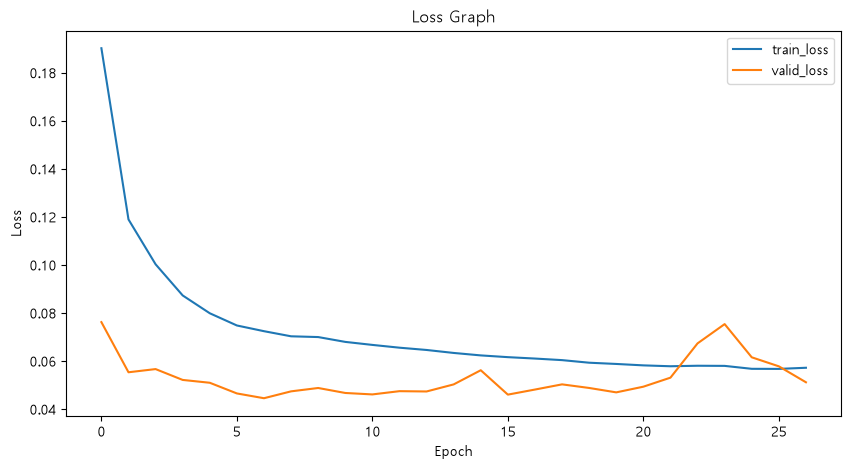

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_graph, label='train_loss')
plt.plot(valid_loss_graph, label='valid_loss')
plt.legend()
plt.title('Loss Graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

## 4. 모델 검증

앞서 만들어둔 테스트 셋을 이용하여 실제 모델의 성능을 평가하고 시각화한다.

In [31]:
model.load_state_dict(best_model)
model.eval()

pred_graph = []
y_graph = []

with torch.no_grad():
    for x, c, y in test_loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        pred = model(x, c)

        # 예측치와 실제 결과를 원래 단위로 되돌린다.
        pred_transform = power_scaler.inverse_transform(
            pred.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)
        y_transform = power_scaler.inverse_transform(
            y.detach().cpu().numpy().reshape(-1, 1)
        ).reshape(-1, horizon_size)

        pred_graph.append(pred_transform)
        y_graph.append(y_transform)

pred_graph = np.concatenate(pred_graph, axis=0)
y_graph = np.concatenate(y_graph, axis=0)
loss = y_graph - pred_graph

print(f'예측 shape : {pred_graph.shape}')

예측 shape : (4610, 96)


오차가 가장 컸던 5일과 작았던 5일의 실제값과 예측치를 그래프로 나타낸다.

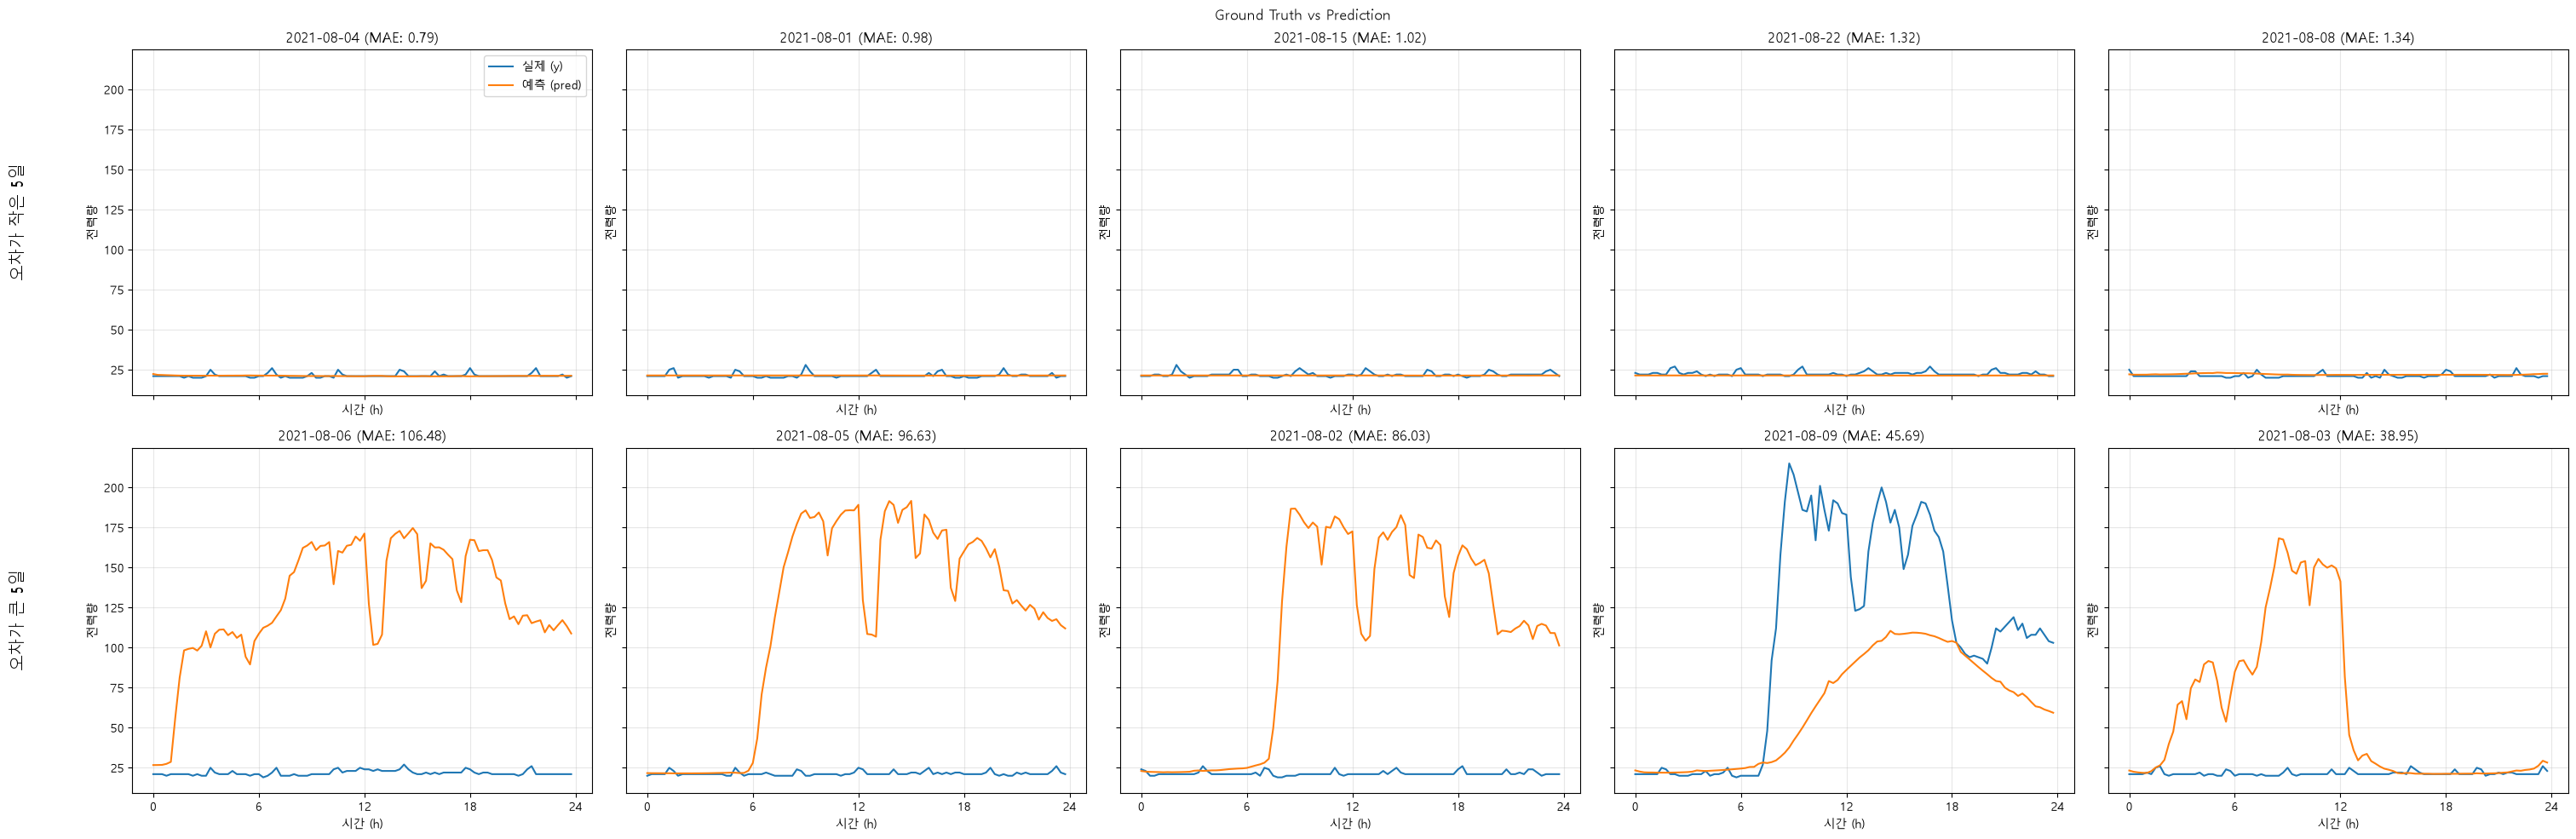

In [32]:
# 테스트 구간에서 하루 단위 예측만 선택
test_dates = t_start[test_split]
midnight = (test_dates.hour == 0) & (test_dates.minute == 0)
 
pred_d = pred_graph[midnight]              
y_d    = y_graph[midnight]               
err_d  = y_d - pred_d                       
dates  = test_dates[midnight].normalize()     

# 날짜별 MAE를 계산하고 오차가 큰 날과 작은 날을 선택
# MAE값 추출
daily_mae = pd.Series(np.abs(err_d).mean(axis=1), index=dates).sort_index()

 # 오차가 가장 큰 날짜와 작은 날짜 추출
low_dates  = daily_mae.nsmallest(5).index     
high_dates = daily_mae.nlargest(5).index      
selected   = [low_dates, high_dates]
row_labels = ['오차가 작은 5일', '오차가 큰 5일']
 
hours = np.arange(horizon_size) * 15 / 60     
pos = lambda ds: daily_mae.index.get_indexer(ds)   
 
# 선택한 날짜들의 실제값과 예측값을 비교
fig, axes = plt.subplots(2, 5, figsize=(30, 10), sharex=True, sharey=True)
 
for r, (row_axes, ds) in enumerate(zip(axes, selected)):
    for ax, date, i in zip(row_axes, ds, pos(ds)):
        ax.plot(hours, y_d[i], label='실제 (y)')
        ax.plot(hours, pred_d[i], label='예측 (pred)')
        ax.set_title(f"{date:%Y-%m-%d} (MAE: {daily_mae[date]:.2f})")
        ax.set_xlabel('시간 (h)')
        ax.set_ylabel('전력량')
        ax.set_xticks(range(0, 25, 6))
        ax.grid(alpha=0.3)
    row_axes[0].text(-0.25, 0.5, row_labels[r], transform=row_axes[0].transAxes,
                     rotation=90, va='center', ha='center', fontsize=14)
 
axes[0, 0].legend()
fig.suptitle('Ground Truth vs Prediction')
fig.tight_layout()
plt.show()

오차가 가장 컸던 5일과 작았던 5일의 시간에 따른 오차값을 그래프로 나타낸다.

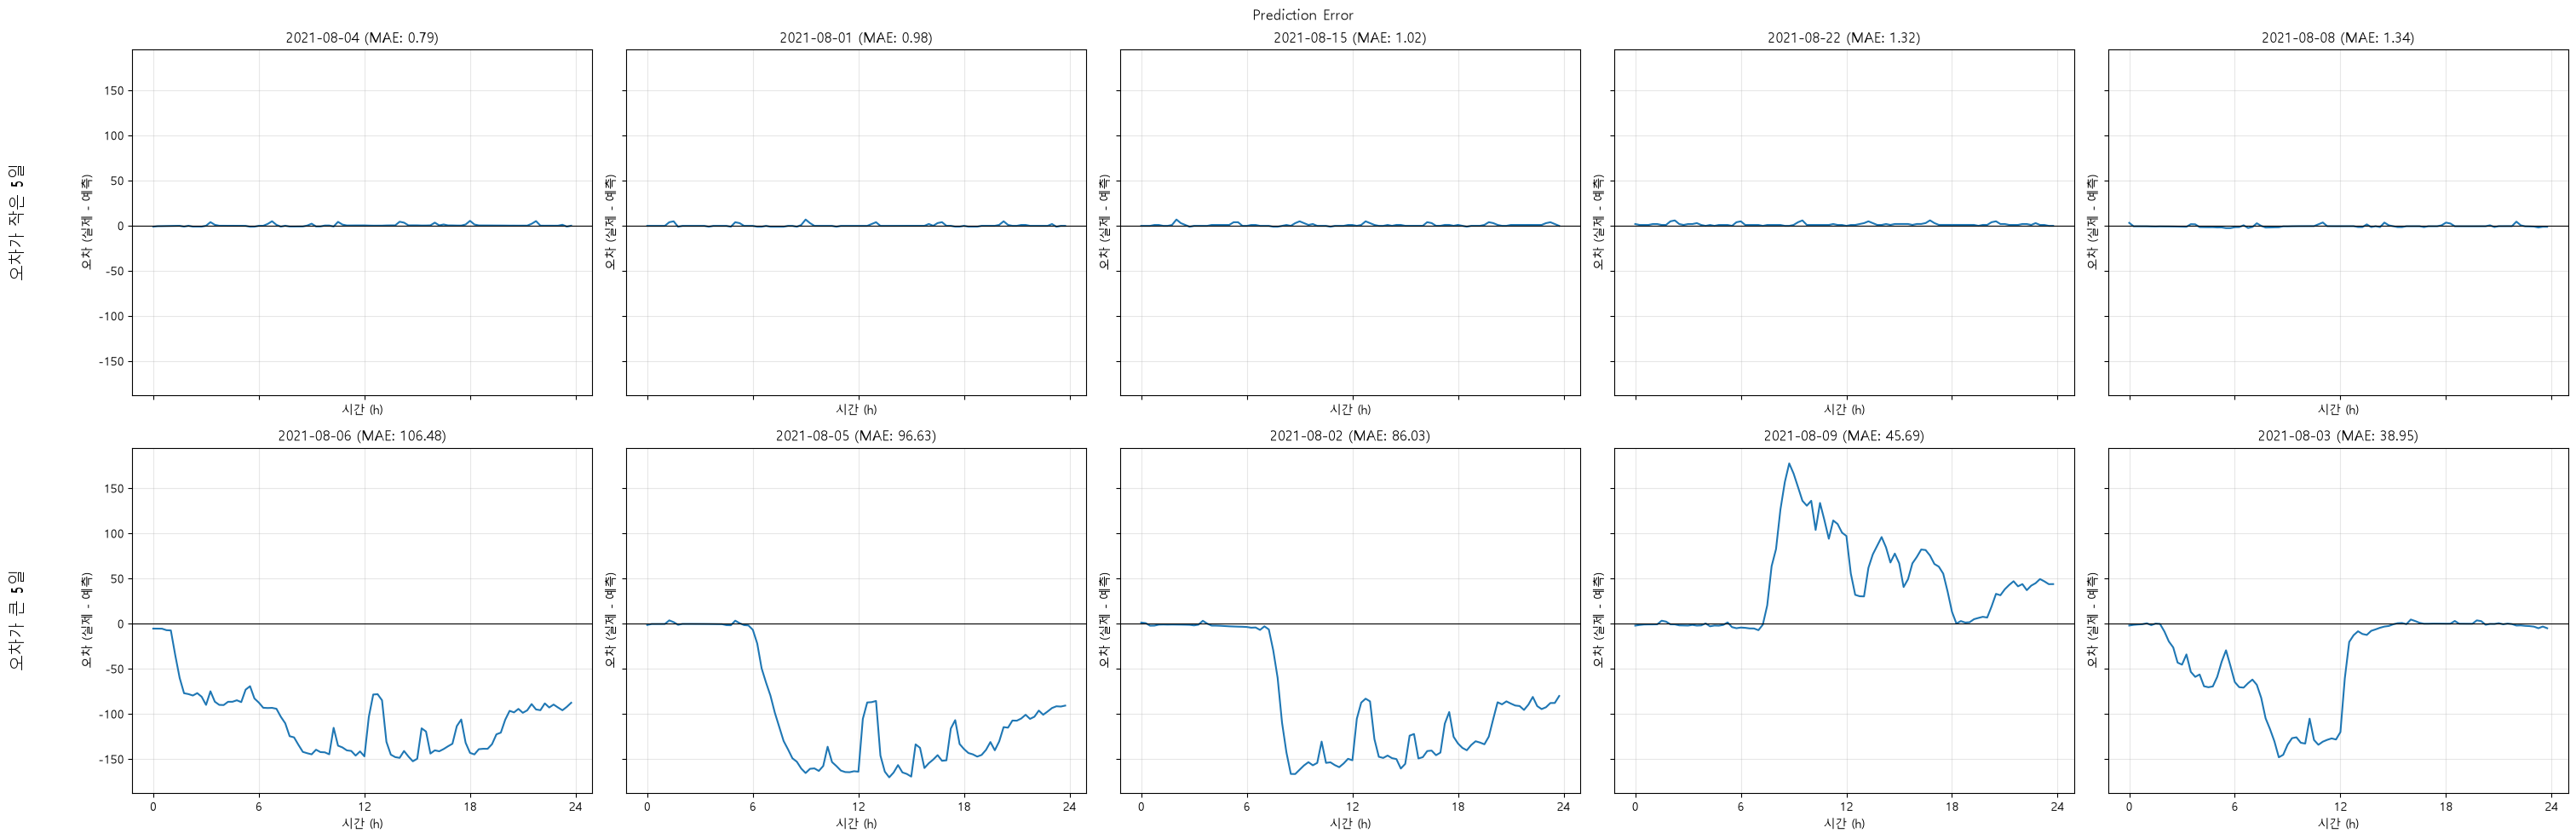

In [33]:
# 오차가 작은 날짜와 큰 날짜의 시간대별 오차를 비교
fig, axes = plt.subplots(2, 5, figsize=(30, 10), sharex=True, sharey=True)
 
for r, (row_axes, ds) in enumerate(zip(axes, selected)):
    for ax, date, i in zip(row_axes, ds, pos(ds)):
        ax.plot(hours, err_d[i])
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f"{date:%Y-%m-%d} (MAE: {daily_mae[date]:.2f})")
        ax.set_xlabel('시간 (h)')
        ax.set_ylabel('오차 (실제 - 예측)')
        ax.set_xticks(range(0, 25, 6))
        ax.grid(alpha=0.3)
    row_axes[0].text(-0.25, 0.5, row_labels[r], transform=row_axes[0].transAxes,
                     rotation=90, va='center', ha='center', fontsize=14)
 
fig.suptitle('Prediction Error')
fig.tight_layout()
plt.show()

날짜별 평균 오차를 그래프로 나타낸다.

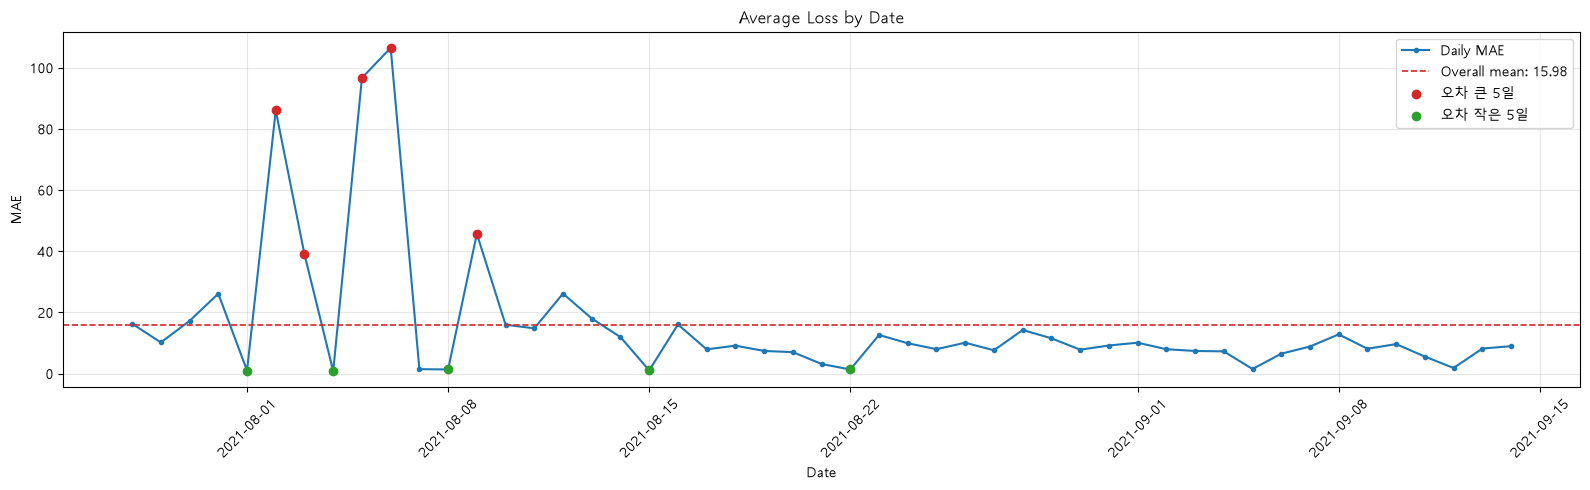

In [34]:
# 날짜별 MAE와 전체 평균 오차를 시계열로 표시
plt.figure(figsize=(16, 5))
plt.plot(daily_mae.index, daily_mae.values, marker='o', markersize=3,
         linewidth=1.5, label='Daily MAE')
plt.axhline(daily_mae.mean(), color='tab:red', linestyle='--', linewidth=1.2,
            label=f'Overall mean: {daily_mae.mean():.2f}')
# 오차가 큰 날짜와 작은 날짜를 각각 강조
plt.scatter(high_dates, daily_mae[high_dates], color='tab:red', zorder=3,
            label='오차 큰 5일')
plt.scatter(low_dates, daily_mae[low_dates], color='tab:green', zorder=3,
            label='오차 작은 5일')
plt.title('Average Loss by Date')
plt.xlabel('Date')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 모델 저장

In [ ]:
# 검증 손실이 가장 낮았던 모델의 가중치를 저장한다.
torch.save(model.state_dict(), 'baseline_lstm.pth')
print('모델 저장 완료: baseline_lstm.pth')